In [1]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

Array shape: (1397, 1258)
CRS: EPSG:26717


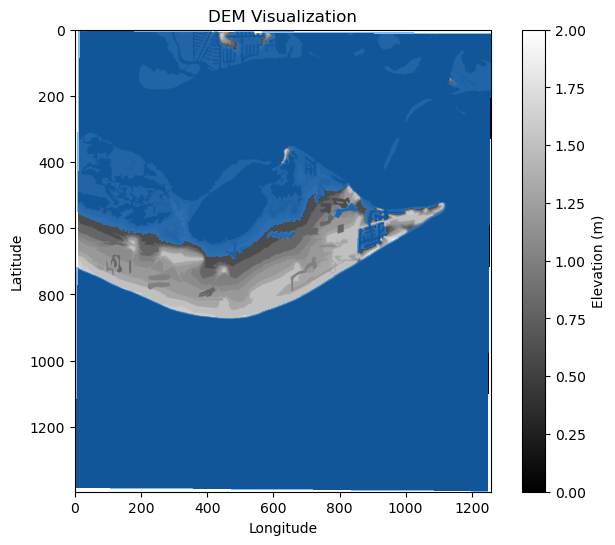

Min Elevation: 0.0 m
Max Elevation: 2.0 m
No-Data Value: -32767.0


In [14]:
dem_path = './Sanibel/sanibel.dem'  # Replace with the actual path

with rasterio.open(dem_path) as src:
    # Access the data as a NumPy array
    dem_array = src.read(1)  # Reads the first band

    # Access metadata
    profile = src.profile
    crs = src.crs
    bounds = src.bounds

    # Perform operations with the data (e.g., visualize, analyze)
        # Example: Print array shape and CRS
    print(f"Array shape: {dem_array.shape}")
    print(f"CRS: {crs}")

dem_array = np.where(dem_array == src.nodata, np.nan, dem_array)

sea_level = 0.5
slr_correction = 0.4637622 # Calculated using historical satellite data.
flooded_mask = dem_array <= (sea_level + slr_correction)

# Plot DEM using the terrain colormap
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.imshow(dem_array, cmap="grey", origin="upper") 
plt.colorbar(cax, label="Elevation (m)")

# Overlay the flooded areas in dark blue using a contour plot

if np.any(flooded_mask):  # Ensure we have flooded areas before plotting 
    ax.contourf(dem_array, levels=[np.nanmin(dem_array), sea_level], colors=["dodgerblue"], alpha=0.6)
    
plt.title('DEM Visualization')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

print(f"Min Elevation: {np.nanmin(dem_array)} m")
print(f"Max Elevation: {np.nanmax(dem_array)} m")
print(f"No-Data Value: {src.nodata}")